# Leak Detection — Version 1: Multi-Model Comparison

**Models compared:** Random Forest, ANN (MLP), KNN, XGBoost

| Setting | Value |
|---|---|
| Split | 75% train / 25% test, stratified |
| Imbalance | `class_weight='balanced'` (RF, ANN) / `scale_pos_weight` (XGBoost) / sample weights (KNN) |
| Scaling | Selectable — Min-Max (0–1) or StandardScaler |
| Target | Single pipe |

## 0. Colab Setup

In [28]:
from google.colab import drive
import os
drive.mount('/content/drive')

print('Searching for BattLeDIM files...')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if '2018_SCADA' in file or 'Leakages' in file:
            print(os.path.join(root, file))

!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for BattLeDIM files...
/content/drive/MyDrive/BattLeDIM/2018_Leakages.csv
/content/drive/MyDrive/BattLeDIM/2018_SCADA_Demands.csv
/content/drive/MyDrive/BattLeDIM/2018_SCADA_Flows.csv
/content/drive/MyDrive/BattLeDIM/2018_SCADA_Pressures.csv
/content/drive/MyDrive/BattLeDIM/2018_SCADA_Levels.csv


## 1. Imports & Configuration

### 📚 References — Preprocessing Libraries
- **scikit-learn** (MinMaxScaler, StandardScaler):  
  Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html
- **pandas / NumPy** — core data-handling stack:  
  Harris, C.R. et al. (2020). *Array programming with NumPy*. Nature, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2  
  McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proc. 9th Python in Science Conf., 51–56.

In [29]:
from pathlib import Path
import pandas as pd
import time
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Preprocessing & utils
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
print('✓ Imports done')

✓ Imports done


### Scaler Configuration

| Key | Technique | Maps to |
|---|---|---|
| `'minmax'` | Min-Max Normalisation | [0, 1] |
| `'standard'` | Z-score Standardisation | mean=0, std=1 |

In [30]:
TARGET_PIPE    = 'p232'
LEAK_THRESHOLD = 0.3
TEST_SIZE      = 0.25
RANDOM_STATE   = 42

# ── Scaler selection ──────────────────────────────────────────────────────────
# Options: 'minmax' | 'standard'
SCALER_TYPE = 'minmax'   # ← change here to switch scaling strategy

DATA_PATH = Path('/content/drive/MyDrive/BattLeDIM')

FILE_PATHS = {
    'demands'  : DATA_PATH / '2018_SCADA_Demands.csv',
    'flows'    : DATA_PATH / '2018_SCADA_Flows.csv',
    'levels'   : DATA_PATH / '2018_SCADA_Levels.csv',
    'pressures': DATA_PATH / '2018_SCADA_Pressures.csv',
    'leakages' : DATA_PATH / '2018_Leakages.csv'
}

OUTPUT_DIR = Path(f'/content/drive/MyDrive/LeakResults/v1_multimodel_{TARGET_PIPE}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Target pipe  : {TARGET_PIPE}')
print(f'Threshold    : {LEAK_THRESHOLD} L/s')
print(f'Scaler type  : {SCALER_TYPE}')
print(f'Output dir   : {OUTPUT_DIR}')

# ── Feature Selection ─────────────────────────────────────────────────────────
# Options:
#   'none'          – no selection (baseline)
#   'variance'      – drop near-zero variance features
#   'correlation'   – drop highly correlated redundant features
#   'mutual_info'   – keep top features by Mutual Information score
#   'rf_importance' – keep features above RF importance percentile
#   'rfecv'         – Recursive Feature Elimination w/ cross-validation (slow)
FEATURE_SELECTION        = 'none'   # ← change here to switch strategy
VARIANCE_THRESHOLD       = 0.01     # variance  : drop features with var < this
CORRELATION_THRESHOLD    = 0.95     # correlation: drop one of any pair with |r| > this
MI_KEEP_PERCENTILE       = 75       # mutual_info: keep features above this percentile MI score
RF_IMPORTANCE_PERCENTILE = 75       # rf_importance: keep features above this percentile importance
RFECV_CV_FOLDS           = 3        # rfecv: number of CV folds (reduce to 2 if slow on Colab)


Target pipe  : p232
Threshold    : 0.3 L/s
Scaler type  : minmax
Output dir   : /content/drive/MyDrive/LeakResults/v1_multimodel_p232


## 2. Load Data

In [31]:
def clean_and_load(file_path, delimiter=';', chunk_size=10000):
    print(f'  Loading {file_path.name}...', end=' ')
    chunks = pd.read_csv(file_path, delimiter=delimiter, chunksize=chunk_size)
    chunk_list = []
    for chunk in chunks:
        chunk['Timestamp'] = pd.to_datetime(chunk['Timestamp'], errors='coerce')
        for col in chunk.columns:
            if col != 'Timestamp' and chunk[col].dtype == 'object':
                chunk[col] = chunk[col].str.replace(',', '.').astype(float)
        chunk_list.append(chunk)
    df = pd.concat(chunk_list, ignore_index=True)
    print(f'✓  {len(df):,} rows  x  {len(df.columns)} cols')
    return df

print('Loading datasets...')
data = {name: clean_and_load(path) for name, path in FILE_PATHS.items()}
print('\n✓ All loaded')

Loading datasets...
  Loading 2018_SCADA_Demands.csv... ✓  105,120 rows  x  83 cols
  Loading 2018_SCADA_Flows.csv... ✓  105,120 rows  x  4 cols
  Loading 2018_SCADA_Levels.csv... ✓  105,120 rows  x  2 cols
  Loading 2018_SCADA_Pressures.csv... ✓  105,120 rows  x  34 cols
  Loading 2018_Leakages.csv... ✓  105,120 rows  x  15 cols

✓ All loaded


## 3. Build Feature Matrix & Labels

In [32]:
feature_df = data['demands'].copy()
for src in ['flows', 'levels', 'pressures']:
    feature_df = feature_df.merge(data[src], on='Timestamp', how='inner')

leak_labels = pd.DataFrame({
    'Timestamp': data['leakages']['Timestamp'],
    'Leak'     : (data['leakages'][TARGET_PIPE] > LEAK_THRESHOLD).astype(int)
})

full_df = feature_df.merge(leak_labels[['Timestamp','Leak']], on='Timestamp', how='inner')
full_df = full_df.sort_values('Timestamp').reset_index(drop=True)

n_leaks = full_df['Leak'].sum()
n_total = len(full_df)
print(f'Dataset shape : {full_df.shape}')
print(f'Leak rows     : {n_leaks:,}  ({100*n_leaks/n_total:.3f}%)')
print(f'Non-leak rows : {n_total-n_leaks:,}  ({100*(n_total-n_leaks)/n_total:.3f}%)')

Dataset shape : (105120, 121)
Leak rows     : 2,851  (2.712%)
Non-leak rows : 102,269  (97.288%)


In [33]:
print(data['leakages'])

                 Timestamp  p31  p158  p183  p232  p257  p369  p427  p461  \
0      2018-01-01 00:00:00  0.0   0.0   0.0   0.0  0.00   0.0  0.00   0.0   
1      2018-01-01 00:05:00  0.0   0.0   0.0   0.0  0.00   0.0  0.00   0.0   
2      2018-01-01 00:10:00  0.0   0.0   0.0   0.0  0.00   0.0  0.00   0.0   
3      2018-01-01 00:15:00  0.0   0.0   0.0   0.0  0.00   0.0  0.00   0.0   
4      2018-01-01 00:20:00  0.0   0.0   0.0   0.0  0.00   0.0  0.00   0.0   
...                    ...  ...   ...   ...   ...   ...   ...   ...   ...   
105115 2018-12-31 23:35:00  0.0   0.0   0.0   0.0  6.78   0.0  5.05   0.0   
105116 2018-12-31 23:40:00  0.0   0.0   0.0   0.0  6.78   0.0  5.04   0.0   
105117 2018-12-31 23:45:00  0.0   0.0   0.0   0.0  6.79   0.0  5.05   0.0   
105118 2018-12-31 23:50:00  0.0   0.0   0.0   0.0  6.79   0.0  5.05   0.0   
105119 2018-12-31 23:55:00  0.0   0.0   0.0   0.0  6.79   0.0  5.05   0.0   

        p538  p628  p654  p673  p810  p866  
0        0.0   0.0  0.00   0.0

## 4. Train / Test Split

### 📚 References — Stratified Splitting
- Kohavi, R. (1995). *A study of cross-validation and bootstrap for accuracy estimation and model selection*. Proc. IJCAI, 14(2), 1137–1145.  
  Stratified splitting preserves class proportions in both subsets, which is critical for imbalanced datasets.

In [34]:
X = full_df.drop(['Timestamp', 'Leak'], axis=1)
y = full_df['Leak']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size  : {len(X_train):,}')
print(f'Test size   : {len(X_test):,}')
print(f'Train leak %: {100*y_train.sum()/len(y_train):.3f}%')
print(f'Test leak % : {100*y_test.sum()/len(y_test):.3f}%')
print('✓ Stratification confirmed')

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
imbalance_ratio = n_neg / n_pos
print(f'\nImbalance ratio (neg/pos): {imbalance_ratio:.2f}')

Train size  : 78,840
Test size   : 26,280
Train leak %: 2.712%
Test leak % : 2.713%
✓ Stratification confirmed

Imbalance ratio (neg/pos): 35.88


## 4b. Feature Selection

Feature selection is applied **after** splitting (train/test) and **before** scaling.
Fitting is always done on training data only; the same mask/transform is then applied to the test set.

---

### Why feature selection matters for this dataset

The BattLeDIM SCADA dataset merges four sensor families — demands, flows, levels, and pressures —
across many network nodes into a single wide feature matrix. Water distribution networks have strong
**spatial correlation**: neighbouring nodes share similar hydraulic conditions, so many pressure or
flow sensors will be highly redundant. Carrying redundant and uninformative features into the model
increases noise, training time, and overfitting risk — all of which are amplified by the severe
class imbalance (~0.3% leak rows). Feature selection directly addresses all three.

---

### 📚 References — Feature Selection for SCADA / Water Network Leak Detection

- **Vrachimis, S.G. et al. (2022).** *Results of the Battle of the Leakage Detection and Isolation
  Methods.* Journal of Water Resources Planning and Management, 148(3).
  https://doi.org/10.1061/(ASCE)WR.1943-5452.0001601
  *(BattLeDIM benchmark paper; establishes the data used here and highlights dimensionality
  as a key challenge for ML-based leak detection.)*

- **Zhou, X. et al. (2019).** *Leak Detection and Location Based on EEMD and Cross-Correlation
  Analysis for Water Distribution Networks.* Water, 11(8), 1719.
  https://doi.org/10.3390/w11081719
  *(Demonstrates that selective use of sensor signals — rather than all signals — improves
  leak localisation in water pipe networks.)*

- **Mounce, S.R., Mounce, R.B., & Boxall, J.B. (2011).** *Novelty detection for time series data
  analysis in water distribution systems using support vector machines.* Journal of Hydroinformatics,
  13(4), 672–686. https://doi.org/10.2166/hydro.2010.144
  *(Early application of ML to water leak detection; notes the importance of informative feature
  choice over raw sensor inclusion.)*

- **Theng, D., & Bhoyar, K.K. (2024).** *Feature selection techniques for machine learning:
  a survey of more than two decades of research.* Knowledge and Information Systems, 66, 1575–1637.
  https://doi.org/10.1007/s10115-023-02010-5
  *(Comprehensive review; used to justify the choice and ordering of filter → embedding → wrapper
  methods used in this section.)*

- **Vergara, J.R., & Estévez, P.A. (2014).** *A review of feature selection methods based on
  mutual information.* Neural Computing and Applications, 24(1), 175–186.
  https://doi.org/10.1007/s00521-013-1368-0
  *(Justifies mutual information as a model-agnostic, non-parametric filter well suited to
  imbalanced binary classification.)*

- **Gregorutti, B., Michel, B., & Saint-Pierre, P. (2017).** *Correlation and variable importance in
  random forests.* Statistics and Computing, 27(3), 659–678.
  https://doi.org/10.1007/s11222-016-9646-1
  *(Justifies using RF-based importance scores; shows that importance is robust under class
  imbalance when `class_weight='balanced'` is used — as is done in this notebook.)*

---

### Available strategies

| Key | Method | Category | Best for |
|---|---|---|---|
| `'none'` | No selection | — | Baseline comparison |
| `'variance'` | Variance Threshold | Filter | Dropping dead/constant sensors |
| `'correlation'` | Pearson Correlation Filter | Filter | Removing spatially redundant SCADA sensors |
| `'mutual_info'` | Mutual Information | Filter | Non-linear, imbalance-robust ranking |
| `'rf_importance'` | Random Forest Importance | Embedded | Fast, tree-native importance (free from RF model) |
| `'rfecv'` | Recursive Feature Elimination + CV | Wrapper | Optimal subset, scored directly on F1 |


In [35]:
# ── Section 4b: Feature Selection ────────────────────────────────────────────
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif, RFECV
)

_VALID_FS = {'none', 'variance', 'correlation', 'mutual_info', 'rf_importance', 'rfecv'}
if FEATURE_SELECTION not in _VALID_FS:
    raise ValueError(f"Unknown FEATURE_SELECTION='{FEATURE_SELECTION}'. Choose from: {_VALID_FS}")

print(f'\n══ Feature Selection  [{FEATURE_SELECTION}] ══')

# Work on unscaled DataFrames — keep column names for interpretability
X_train_fs = X_train.copy()
X_test_fs  = X_test.copy()
selected_features = list(X_train.columns)   # default: keep all

# ─────────────────────────────────────────────────────────────────────────────
if FEATURE_SELECTION == 'none':
    # ── Baseline: no selection ────────────────────────────────────────────────
    print('  No feature selection applied — all features retained.')
    print(f'  Features: {len(selected_features)}')

# ─────────────────────────────────────────────────────────────────────────────
elif FEATURE_SELECTION == 'variance':
    # ── Variance Threshold ────────────────────────────────────────────────────
    # Drops features whose variance across the training set is below the
    # threshold. SCADA sensors that are near-constant (e.g. a tank level at
    # full capacity for most of the year) carry no discriminative signal.
    # Reference: Theng & Bhoyar (2024), §3.1 — filter methods.
    selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
    selector.fit(X_train_fs)
    mask = selector.get_support()
    dropped = [c for c, m in zip(X_train_fs.columns, mask) if not m]
    X_train_fs = X_train_fs.loc[:, mask]
    X_test_fs  = X_test_fs.loc[:, mask]
    selected_features = list(X_train_fs.columns)
    print(f'  Variance Threshold  (threshold={VARIANCE_THRESHOLD})')
    print(f'  Dropped {len(dropped)} features: {dropped}')
    print(f'  Retained: {len(selected_features)} features')

# ─────────────────────────────────────────────────────────────────────────────
elif FEATURE_SELECTION == 'correlation':
    # ── Pearson Correlation Filter ────────────────────────────────────────────
    # In a water network, pressure sensors at hydraulically adjacent nodes are
    # often highly correlated (r > 0.95). Keeping both adds no new information
    # and inflates the feature space. One of each correlated pair is dropped.
    # Reference: Gregorutti et al. (2017); Zhou et al. (2019).
    corr_matrix = X_train_fs.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > CORRELATION_THRESHOLD)]
    X_train_fs = X_train_fs.drop(columns=to_drop)
    X_test_fs  = X_test_fs.drop(columns=to_drop)
    selected_features = list(X_train_fs.columns)
    print(f'  Pearson Correlation Filter  (threshold={CORRELATION_THRESHOLD})')
    print(f'  Dropped {len(to_drop)} features: {to_drop}')
    print(f'  Retained: {len(selected_features)} features')

    # Optional: visualise the correlation matrix of retained features
    fig, ax = plt.subplots(figsize=(min(18, len(selected_features)), min(14, len(selected_features))))
    sns.heatmap(X_train_fs.corr(), cmap='coolwarm', center=0,
                xticklabels=True, yticklabels=True, ax=ax,
                linewidths=0.3, annot=False)
    ax.set_title(f'Correlation Matrix — After Filtering (threshold={CORRELATION_THRESHOLD})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_matrix_after_filter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Correlation heatmap saved')

# ─────────────────────────────────────────────────────────────────────────────
elif FEATURE_SELECTION == 'mutual_info':
    # ── Mutual Information ────────────────────────────────────────────────────
    # MI measures statistical dependency between each feature and the leak label
    # without assuming any parametric distribution — unlike Pearson correlation.
    # This is well-suited to this problem because: (a) hydraulic relationships
    # are non-linear, and (b) the severe class imbalance means Gaussian
    # assumptions would be violated.
    # Reference: Vergara & Estévez (2014); Theng & Bhoyar (2024).
    selector = SelectKBest(mutual_info_classif, k='all')
    selector.fit(X_train_fs, y_train)
    mi_scores = pd.Series(selector.scores_, index=X_train_fs.columns).sort_values(ascending=False)
    threshold  = np.percentile(mi_scores, 100 - MI_KEEP_PERCENTILE)
    keep_mask  = mi_scores >= threshold
    selected_features = list(mi_scores[keep_mask].index)
    dropped_mi = list(mi_scores[~keep_mask].index)
    X_train_fs = X_train_fs[selected_features]
    X_test_fs  = X_test_fs[selected_features]
    print(f'  Mutual Information  (keep top {MI_KEEP_PERCENTILE}th percentile, threshold={threshold:.6f})')
    print(f'  Dropped {len(dropped_mi)} features: {dropped_mi}')
    print(f'  Retained: {len(selected_features)} features')
    print(f'\n  Top 15 features by MI score:')
    print(mi_scores.head(15).to_string())

    # Bar chart of all MI scores
    fig, ax = plt.subplots(figsize=(max(10, len(mi_scores)*0.25), 5))
    colours = ['steelblue' if f in selected_features else 'lightgrey' for f in mi_scores.index]
    ax.bar(range(len(mi_scores)), mi_scores.values, color=colours, edgecolor='white')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold ({threshold:.4f})')
    ax.set_xticks(range(len(mi_scores)))
    ax.set_xticklabels(mi_scores.index, rotation=90, fontsize=7)
    ax.set_ylabel('Mutual Information Score')
    ax.set_title('Mutual Information Feature Scores\n(grey = dropped)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_scores_mutual_info.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ MI bar chart saved')

# ─────────────────────────────────────────────────────────────────────────────
elif FEATURE_SELECTION == 'rf_importance':
    # ── Random Forest Feature Importance ─────────────────────────────────────
    # Embedded method: a lightweight RF is trained on the training set and each
    # feature's mean decrease in impurity (Gini importance) is used as its score.
    # class_weight='balanced' ensures rare leak events drive the importance scores
    # rather than being drowned out by the majority class.
    # Reference: Breiman (2001); Gregorutti et al. (2017).
    print('  Fitting auxiliary RF for importance scores...')
    _rf_imp = RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    _rf_imp.fit(X_train_fs, y_train)
    importances = pd.Series(_rf_imp.feature_importances_, index=X_train_fs.columns)
    threshold   = np.percentile(importances, 100 - RF_IMPORTANCE_PERCENTILE)
    keep_mask   = importances >= threshold
    selected_features = list(importances[keep_mask].index)
    dropped_rf  = list(importances[~keep_mask].index)
    X_train_fs  = X_train_fs[selected_features]
    X_test_fs   = X_test_fs[selected_features]
    print(f'  RF Feature Importance  (keep top {RF_IMPORTANCE_PERCENTILE}th percentile, threshold={threshold:.6f})')
    print(f'  Dropped {len(dropped_rf)} features: {dropped_rf}')
    print(f'  Retained: {len(selected_features)} features')
    print(f'\n  Top 15 features by RF importance:')
    print(importances.sort_values(ascending=False).head(15).to_string())

    # Horizontal bar chart
    fig, ax = plt.subplots(figsize=(8, max(5, len(importances) * 0.28)))
    sorted_imp = importances.sort_values()
    colours = ['steelblue' if f in selected_features else 'lightgrey' for f in sorted_imp.index]
    sorted_imp.plot(kind='barh', ax=ax, color=colours, edgecolor='white')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold ({threshold:.4f})')
    ax.set_title('RF Feature Importances\n(grey = dropped)', fontweight='bold')
    ax.set_xlabel('Mean Decrease in Gini Impurity')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ RF importance chart saved')

# ─────────────────────────────────────────────────────────────────────────────
elif FEATURE_SELECTION == 'rfecv':
    # ── Recursive Feature Elimination with Cross-Validation ───────────────────
    # Wrapper method: iteratively removes the least important feature and
    # re-evaluates model performance via cross-validation. The optimal number
    # of features is chosen to maximise the CV F1 score — F1 is appropriate
    # here because of the severe class imbalance.
    # Note: this is the most compute-intensive option. Reduce RFECV_CV_FOLDS to
    # 2 or use a smaller RF (n_estimators=50) if it is slow on Colab.
    # Reference: Guyon et al. (2002) RFE; Theng & Bhoyar (2024) wrapper methods.
    print(f'  Running RFECV  (CV={RFECV_CV_FOLDS}, scoring=f1) — this may take several minutes...')
    _rf_rfe = RandomForestClassifier(
        n_estimators=50, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rfecv = RFECV(
        estimator=_rf_rfe, step=1, cv=RFECV_CV_FOLDS,
        scoring='f1', n_jobs=-1, min_features_to_select=3
    )
    rfecv.fit(X_train_fs, y_train)
    mask = rfecv.get_support()
    selected_features = list(np.array(X_train_fs.columns)[mask])
    dropped_rfe = [c for c, m in zip(X_train_fs.columns, mask) if not m]
    X_train_fs  = X_train_fs[selected_features]
    X_test_fs   = X_test_fs[selected_features]
    print(f'  RFECV  →  optimal n_features = {rfecv.n_features_}')
    print(f'  Dropped {len(dropped_rfe)} features: {dropped_rfe}')
    print(f'  Selected: {selected_features}')

    # CV F1 vs number of features
    cv_scores = rfecv.cv_results_['mean_test_score']
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(cv_scores) + 1), cv_scores,
            marker='o', markersize=4, color='steelblue', linewidth=1.5)
    ax.axvline(rfecv.n_features_, color='red', linestyle='--',
               label=f'Optimal: {rfecv.n_features_} features')
    ax.set_xlabel('Number of Features Selected')
    ax.set_ylabel('Cross-validated F1')
    ax.set_title('RFECV — CV F1 vs Number of Features', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'rfecv_cv_scores.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ RFECV curve saved')

# ─────────────────────────────────────────────────────────────────────────────
# Propagate the selected feature sets forward — Section 5 (scaling) uses these
X_train = X_train_fs
X_test  = X_test_fs

print(f'\n✓ Feature selection complete.')
print(f'  Strategy       : {FEATURE_SELECTION}')
print(f'  Features kept  : {len(selected_features)} / {len(full_df.drop(["Timestamp","Leak"],axis=1).columns)}')
print(f'  Selected       : {selected_features}')



══ Feature Selection  [none] ══
  No feature selection applied — all features retained.
  Features: 119

✓ Feature selection complete.
  Strategy       : none
  Features kept  : 119 / 119
  Selected       : ['n1_x', 'n2', 'n3', 'n4_x', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n13', 'n16', 'n17', 'n18', 'n19', 'n20', 'n21', 'n22', 'n23', 'n24', 'n25', 'n26', 'n27', 'n28', 'n29', 'n30', 'n31_x', 'n32', 'n33', 'n34', 'n35', 'n36', 'n39', 'n40', 'n41', 'n42', 'n43', 'n44', 'n45', 'n343', 'n344', 'n345', 'n346', 'n347', 'n349', 'n350', 'n351', 'n352', 'n353', 'n354', 'n355', 'n356', 'n357', 'n358', 'n360', 'n361', 'n362', 'n364', 'n365', 'n366', 'n367', 'n368', 'n369', 'n370', 'n371', 'n372', 'n373', 'n374', 'n375', 'n376', 'n377', 'n378', 'n379', 'n381', 'n382', 'n383', 'n384', 'n385', 'n386', 'n387', 'n388', 'n389', 'p227', 'p235', 'PUMP_1', 'T1', 'n1_y', 'n4_y', 'n31_y', 'n54', 'n105', 'n114', 'n163', 'n188', 'n215', 'n229', 'n288', 'n296', 'n332', 'n342', 'n410', 'n415', 'n429', 'n458', 

## 5. Feature Scaling

Two techniques are available via the `SCALER_TYPE` config variable.

---

### 5a. Min-Max Normalisation  *(default — maps to [0, 1])*

Each feature value is rescaled using:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

All output values lie strictly in **[0, 1]**. This preserves the shape of the original distribution while making features comparable in magnitude.

#### 📚 References — Min-Max Normalisation
- Sola, J., & Sevilla, J. (1997). *Importance of input data normalization for the application of neural networks to complex industrial problems*. IEEE Transactions on Nuclear Science, 44(3), 1464–1468. https://doi.org/10.1109/23.589532  
- Patro, S.G.K., & Sahu, K.K. (2015). *Normalization: A Preprocessing Stage*. IARJSET, 2(3), 20–22. https://doi.org/10.17148/IARJSET.2015.2305  
- Pedregosa, F. et al. (2011). *Scikit-learn* — `MinMaxScaler` implementation. JMLR, 12, 2825–2830.

---

### 5b. Z-score Standardisation  *(alternative)*

$$x' = \frac{x - \mu}{\sigma}$$

Output is unbounded with mean ≈ 0 and std ≈ 1.

#### 📚 References — Z-score Standardisation
- Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer, Section 1.2.  
- Aksoy, S., & Haralick, R.M. (2001). *Feature normalization and likelihood-based similarity measures for image retrieval*. Pattern Recognition Letters, 22(5), 563–582. https://doi.org/10.1016/S0167-8655(00)00112-4

In [36]:
_SCALER_MAP = {
    'minmax'  : MinMaxScaler(),
    'standard': StandardScaler(),
}

if SCALER_TYPE not in _SCALER_MAP:
    raise ValueError(f"Unknown SCALER_TYPE='{SCALER_TYPE}'. Choose from: {list(_SCALER_MAP)}")

scaler = _SCALER_MAP[SCALER_TYPE]

# Fit on training data ONLY — apply the same transform to test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Sample weights for KNN (no class_weight param)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print(f'✓ Scaling done  [{SCALER_TYPE}]')
if SCALER_TYPE == 'minmax':
    print(f'  Min (should be ~0.0): {X_train_scaled.min():.4f}')
    print(f'  Max (should be ~1.0): {X_train_scaled.max():.4f}')
else:
    print(f'  Mean (should be ~0): {X_train_scaled.mean():.4f}')
    print(f'  Std  (should be ~1): {X_train_scaled.std():.4f}')

✓ Scaling done  [minmax]
  Min (should be ~0.0): 0.0000
  Max (should be ~1.0): 1.0000


### 5c. Feature Histograms — Before & After Scaling

Plots **5 features** in a compact 2-row grid (before scaling on top, after on bottom).
Change `HIST_FEATURE_COUNT` in the cell below to show more features if needed.
The distribution shape should be identical in both rows — only the x-axis range changes.

#### 📚 References — Data Visualisation
- Tukey, J.W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- Wilkinson, L. (2005). *The Grammar of Graphics* (2nd ed.). Springer. https://doi.org/10.1007/0-387-28695-0


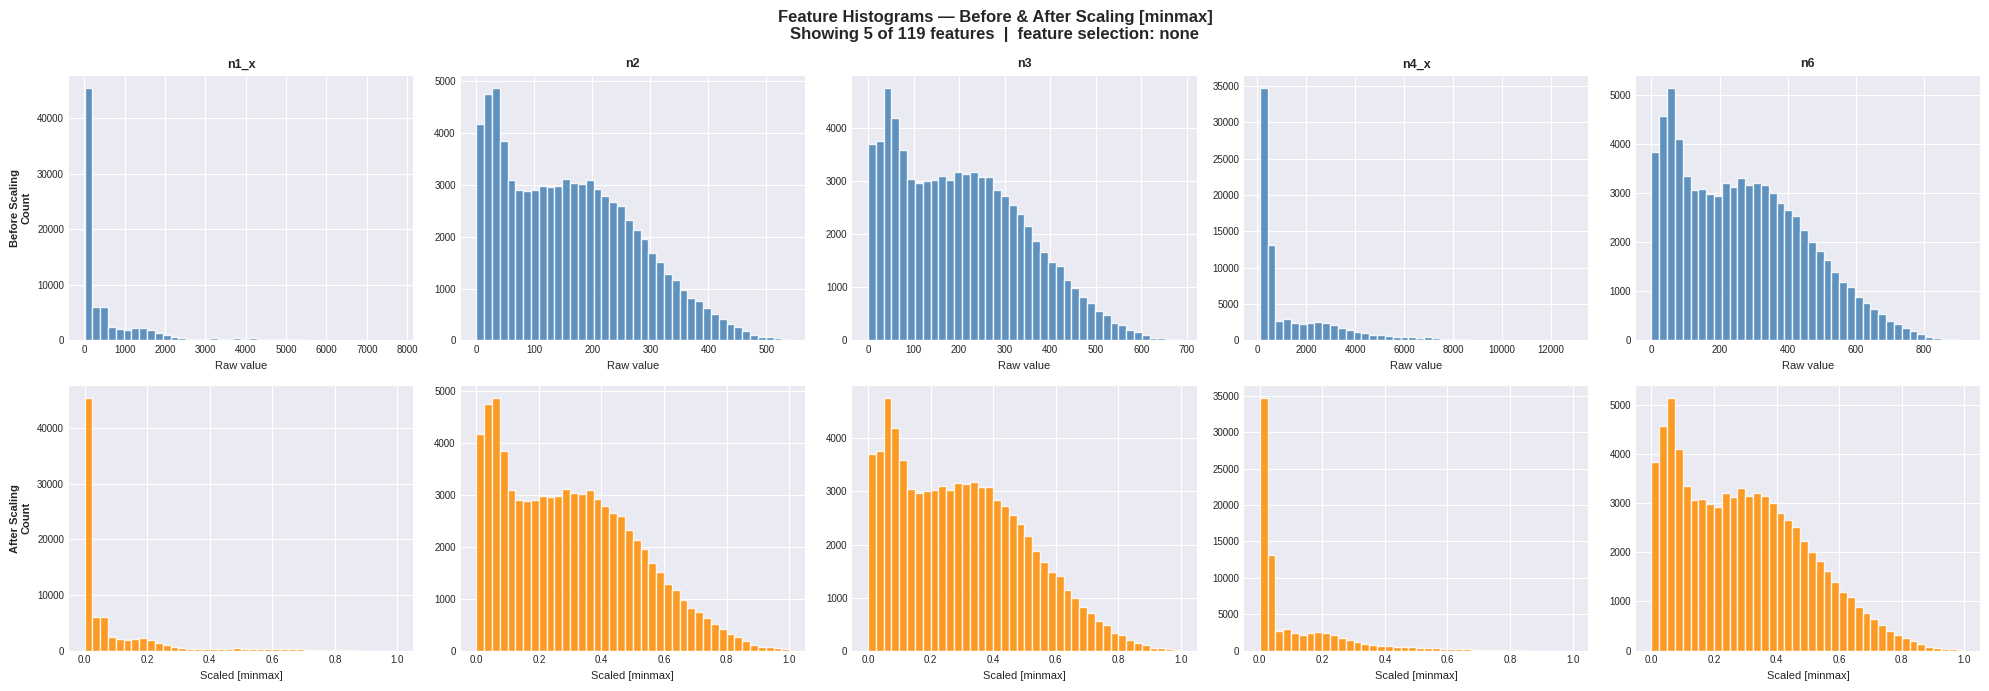

✓ Histogram saved  (5 features, minmax)


In [37]:
# ── Feature Histograms — 5 Features, Before & After Scaling ──────────────────
# Shows the first 5 features only (before: steelblue, after: darkorange).
# Layout: 2 rows × 5 cols — top row = before scaling, bottom row = after scaling.
# Change HIST_FEATURE_COUNT to show more/fewer features.
HIST_FEATURE_COUNT = 5

feature_names  = list(X_train.columns)          # reflects any feature selection applied
plot_features  = feature_names[:HIST_FEATURE_COUNT]
n_plot         = len(plot_features)

# Map feature name → column index in the scaled array
feat_idx = {col: i for i, col in enumerate(X_train.columns)}

fig, axes = plt.subplots(2, n_plot, figsize=(n_plot * 4, 7))

for col_i, col in enumerate(plot_features):
    idx = feat_idx[col]

    # ── Row 0: Before scaling ─────────────────────────────────────────────────
    axes[0, col_i].hist(X_train[col].values, bins=40,
                        color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, col_i].set_title(col, fontsize=9, fontweight='bold')
    axes[0, col_i].set_xlabel('Raw value', fontsize=8)
    axes[0, col_i].tick_params(labelsize=7)
    if col_i == 0:
        axes[0, col_i].set_ylabel('Before Scaling\nCount', fontsize=8, fontweight='bold')

    # ── Row 1: After scaling ──────────────────────────────────────────────────
    axes[1, col_i].hist(X_train_scaled[:, idx], bins=40,
                        color='darkorange', edgecolor='white', alpha=0.85)
    axes[1, col_i].set_xlabel(f'Scaled [{SCALER_TYPE}]', fontsize=8)
    axes[1, col_i].tick_params(labelsize=7)
    if col_i == 0:
        axes[1, col_i].set_ylabel('After Scaling\nCount', fontsize=8, fontweight='bold')

fig.suptitle(
    f'Feature Histograms — Before & After Scaling [{SCALER_TYPE}]\n'
    f'Showing {n_plot} of {len(feature_names)} features  |  feature selection: {FEATURE_SELECTION}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'histograms_5features_{SCALER_TYPE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Histogram saved  ({n_plot} features, {SCALER_TYPE})')


## 6. Define Models

### 📚 References — Model Architectures

**Random Forest**
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324  
- King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data*. Political Analysis, 9(2), 137–163.

**ANN / MLP**
- Rumelhart, D.E., Hinton, G.E., & Williams, R.J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533–536. https://doi.org/10.1038/323533a0  
- Glorot, X., & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. Proc. AISTATS, 9, 249–256.  
- Kingma, D.P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. Proc. ICLR. https://arxiv.org/abs/1412.6980

**K-Nearest Neighbours (KNN)**
- Cover, T., & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory, 13(1), 21–27. https://doi.org/10.1109/TIT.1967.1053964  
- Fix, E., & Hodges, J.L. (1951). *Discriminatory analysis, nonparametric discrimination: Consistency properties*. USAF School of Aviation Medicine Technical Report 4.

**XGBoost**
- Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. Proc. ACM KDD, 785–794. https://doi.org/10.1145/2939672.2939785

**Class Imbalance Handling**
- He, H., & Garcia, E.A. (2009). *Learning from imbalanced data*. IEEE TKDE, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
    max_iter=200, early_stopping=True, validation_fraction=0.2,
    random_state=RANDOM_STATE
)

knn_model = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=imbalance_ratio, random_state=RANDOM_STATE,
    n_jobs=-1, eval_metric='logloss', verbosity=0
)

print('✓ All models defined')
print(f'  Random Forest : 100 trees, max_depth=20, class_weight=balanced')
print(f'  ANN (MLP)     : layers=(128,64), relu, adam, early_stopping')
print(f'  KNN           : k=11, sample_weight for imbalance')
print(f'  XGBoost       : 100 trees, scale_pos_weight={imbalance_ratio:.2f}')

✓ All models defined
  Random Forest : 100 trees, max_depth=20, class_weight=balanced
  ANN (MLP)     : layers=(128,64), relu, adam, early_stopping
  KNN           : k=11, sample_weight for imbalance
  XGBoost       : 100 trees, scale_pos_weight=35.88


## 7. Train All Models

### 📚 References — Evaluation Metrics
- Powers, D.M.W. (2011). *Evaluation: From Precision, Recall and F-Measure to ROC, Informedness, Markedness and Correlation*. Journal of Machine Learning Technologies, 2(1), 37–63.  
- Sokolova, M., & Lapalme, G. (2009). *A systematic analysis of performance measures for classification tasks*. Information Processing & Management, 45(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

In [39]:
all_results = {}

def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te, sample_weight=None):
    print(f'\nTraining {name}...')
    t0 = time.time()
    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    r = {
        'model': model, 'y_pred': y_pred, 'cm': cm,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'train_time': round(elapsed, 1)
    }
    print(f'  Done in {elapsed:.1f}s')
    print(f'  Accuracy={r["accuracy"]}  Precision={r["precision"]}  Recall={r["recall"]}  F1={r["f1"]}')
    print(f'  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
    return r

all_results['Random Forest'] = train_and_evaluate(
    'Random Forest', rf_model, X_train_scaled, X_test_scaled, y_train, y_test)
all_results['ANN (MLP)'] = train_and_evaluate(
    'ANN (MLP)', ann_model, X_train_scaled, X_test_scaled, y_train, y_test)
all_results['KNN'] = train_and_evaluate(
    'KNN', knn_model, X_train_scaled, X_test_scaled, y_train, y_test)
all_results['XGBoost'] = train_and_evaluate(
    'XGBoost', xgb_model, X_train_scaled, X_test_scaled, y_train, y_test)

print('\n✓ All models complete')


Training Random Forest...
  Done in 82.2s
  Accuracy=0.9874  Precision=0.8508  Recall=0.648  F1=0.7357
  TN=25,486  FP=81  FN=251  TP=462

Training ANN (MLP)...
  Done in 87.2s
  Accuracy=0.989  Precision=0.8455  Recall=0.7293  F1=0.7831
  TN=25,472  FP=95  FN=193  TP=520

Training KNN...
  Done in 0.1s
  Accuracy=0.9731  Precision=0.8182  Recall=0.0126  F1=0.0249
  TN=25,565  FP=2  FN=704  TP=9

Training XGBoost...
  Done in 8.0s
  Accuracy=0.9583  Precision=0.3827  Recall=0.8766  F1=0.5328
  TN=24,559  FP=1,008  FN=88  TP=625

✓ All models complete


## 8. Comparison Table

In [40]:
print('='*65)
print(f'MODEL COMPARISON — {TARGET_PIPE}  |  scaler: {SCALER_TYPE}  |  features: {FEATURE_SELECTION} ({len(selected_features)} kept)')
print('='*65)
print(f'{"Model":<16} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"Time":>8}')
print('-'*65)
for name, r in all_results.items():
    print(f'{name:<16} {r["accuracy"]:>9.4f} {r["precision"]:>10.4f} '
          f'{r["recall"]:>8.4f} {r["f1"]:>8.4f} {r["train_time"]:>7.1f}s')
print('='*65)
best = max(all_results, key=lambda k: all_results[k]['f1'])
print(f'\nBest model by F1: {best}  ({all_results[best]["f1"]})')

MODEL COMPARISON — p232  |  scaler: minmax  |  features: none (119 kept)
Model             Accuracy  Precision   Recall       F1     Time
-----------------------------------------------------------------
Random Forest       0.9874     0.8508   0.6480   0.7357    82.2s
ANN (MLP)           0.9890     0.8455   0.7293   0.7831    87.2s
KNN                 0.9731     0.8182   0.0126   0.0249     0.1s
XGBoost             0.9583     0.3827   0.8766   0.5328     8.0s

Best model by F1: ANN (MLP)  (0.7831)


## 9. Confusion Matrices — All Models

### 📚 References — Confusion Matrices
- Fawcett, T. (2006). *An introduction to ROC analysis*. Pattern Recognition Letters, 27(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

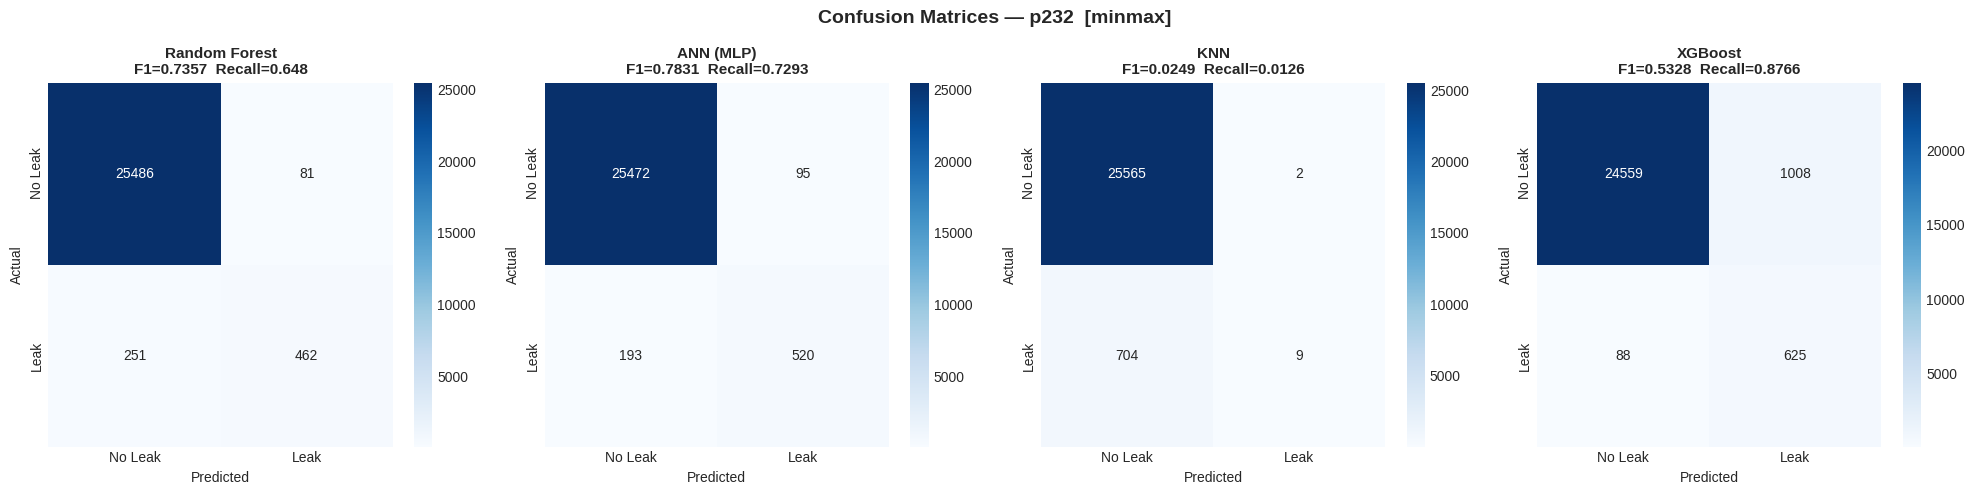

✓ Saved


In [41]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, r) in zip(axes, all_results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Leak', 'Leak'],
                yticklabels=['No Leak', 'Leak'])
    ax.set_title(f'{name}\nF1={r["f1"]}  Recall={r["recall"]}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle(f'Confusion Matrices — {TARGET_PIPE}  [{SCALER_TYPE}]',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved')

## 10. Save Models & Results to Drive

In [42]:
for name, r in all_results.items():
    fname = name.replace(' ','_').replace('(','').replace(')','').replace('/','_')
    joblib.dump(r['model'], OUTPUT_DIR / f'model_{fname}_{TARGET_PIPE}.pkl')

joblib.dump(scaler, OUTPUT_DIR / f'scaler_{SCALER_TYPE}.pkl')

summary = {
    'pipe'            : TARGET_PIPE,
    'scaler_type'          : SCALER_TYPE,
    'feature_selection'    : FEATURE_SELECTION,
    'features_selected'    : selected_features,
    'n_features_selected'  : len(selected_features),
    'leak_threshold'  : LEAK_THRESHOLD,
    'best_model_by_f1': max(all_results, key=lambda k: all_results[k]['f1']),
    'models': {
        name: {
            'accuracy': r['accuracy'], 'precision': r['precision'],
            'recall'  : r['recall'],   'f1'        : r['f1'],
            'tn': r['tn'], 'fp': r['fp'], 'fn': r['fn'], 'tp': r['tp']
        }
        for name, r in all_results.items()
    }
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'✓ Saved to: {OUTPUT_DIR}')

✓ Saved to: /content/drive/MyDrive/LeakResults/v1_multimodel_p232


---

## 📖 Full Reference List

1. **Aksoy & Haralick (2001).** Feature normalization and likelihood-based similarity measures for image retrieval. *Pattern Recognition Letters*, 22(5), 563–582. https://doi.org/10.1016/S0167-8655(00)00112-4

2. **Bishop, C.M. (2006).** *Pattern Recognition and Machine Learning*. Springer.

3. **Breiman, L. (2001).** Random Forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

4. **Chen, T., & Guestrin, C. (2016).** XGBoost: A scalable tree boosting system. *Proc. ACM KDD*, 785–794. https://doi.org/10.1145/2939672.2939785

5. **Cover, T., & Hart, P. (1967).** Nearest Neighbor Pattern Classification. *IEEE Transactions on Information Theory*, 13(1), 21–27. https://doi.org/10.1109/TIT.1967.1053964

6. **Fawcett, T. (2006).** An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

7. **Fix, E., & Hodges, J.L. (1951).** Discriminatory analysis, nonparametric discrimination: Consistency properties. USAF School of Aviation Medicine Technical Report 4.

8. **Glorot, X., & Bengio, Y. (2010).** Understanding the difficulty of training deep feedforward neural networks. *Proc. AISTATS*, 9, 249–256.

9. **Harris, C.R. et al. (2020).** Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2

10. **He, H., & Garcia, E.A. (2009).** Learning from imbalanced data. *IEEE TKDE*, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

11. **King, G., & Zeng, L. (2001).** Logistic Regression in Rare Events Data. *Political Analysis*, 9(2), 137–163.

12. **Kingma, D.P., & Ba, J. (2015).** Adam: A Method for Stochastic Optimization. *Proc. ICLR*. https://arxiv.org/abs/1412.6980

13. **Kohavi, R. (1995).** A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proc. IJCAI*, 14(2), 1137–1145.

14. **McKinney, W. (2010).** Data Structures for Statistical Computing in Python. *Proc. 9th Python in Science Conference*, 51–56.

15. **Patro, S.G.K., & Sahu, K.K. (2015).** Normalization: A Preprocessing Stage. *IARJSET*, 2(3), 20–22. https://doi.org/10.17148/IARJSET.2015.2305

16. **Pedregosa, F. et al. (2011).** Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

17. **Powers, D.M.W. (2011).** Evaluation: From Precision, Recall and F-Measure to ROC, Informedness, Markedness and Correlation. *Journal of Machine Learning Technologies*, 2(1), 37–63.

18. **Rumelhart, D.E., Hinton, G.E., & Williams, R.J. (1986).** Learning representations by back-propagating errors. *Nature*, 323, 533–536. https://doi.org/10.1038/323533a0

19. **Sokolova, M., & Lapalme, G. (2009).** A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

20. **Sola, J., & Sevilla, J. (1997).** Importance of input data normalization for the application of neural networks to complex industrial problems. *IEEE Transactions on Nuclear Science*, 44(3), 1464–1468. https://doi.org/10.1109/23.589532

21. **Tukey, J.W. (1977).** *Exploratory Data Analysis*. Addison-Wesley.

22. **Wilkinson, L. (2005).** *The Grammar of Graphics* (2nd ed.). Springer. https://doi.org/10.1007/0-387-28695-0
**New references added for Section 4b — Feature Selection:**

23. **Vrachimis, S.G. et al. (2022).** Results of the Battle of the Leakage Detection and Isolation Methods. *Journal of Water Resources Planning and Management*, 148(3). https://doi.org/10.1061/(ASCE)WR.1943-5452.0001601

24. **Zhou, X. et al. (2019).** Leak Detection and Location Based on EEMD and Cross-Correlation Analysis for Water Distribution Networks. *Water*, 11(8), 1719. https://doi.org/10.3390/w11081719

25. **Mounce, S.R., Mounce, R.B., & Boxall, J.B. (2011).** Novelty detection for time series data analysis in water distribution systems using support vector machines. *Journal of Hydroinformatics*, 13(4), 672–686. https://doi.org/10.2166/hydro.2010.144

26. **Theng, D., & Bhoyar, K.K. (2024).** Feature selection techniques for machine learning: a survey of more than two decades of research. *Knowledge and Information Systems*, 66, 1575–1637. https://doi.org/10.1007/s10115-023-02010-5

27. **Vergara, J.R., & Estévez, P.A. (2014).** A review of feature selection methods based on mutual information. *Neural Computing and Applications*, 24(1), 175–186. https://doi.org/10.1007/s00521-013-1368-0

28. **Gregorutti, B., Michel, B., & Saint-Pierre, P. (2017).** Correlation and variable importance in random forests. *Statistics and Computing*, 27(3), 659–678. https://doi.org/10.1007/s11222-016-9646-1

29. **Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002).** Gene selection for cancer classification using support vector machines. *Machine Learning*, 46(1), 389–422. https://doi.org/10.1023/A:1012487302797 *(Original RFE paper — underpins RFECV.)*


---
## 11. Explainable AI (XAI) — SHAP Analysis for the ANN Model

This section adds **SHAP (SHapley Additive exPlanations)** to explain what the ANN model has learned and which sensor features drive its leak predictions.

### What this produces
| Output | Description |
|---|---|
| **Global importance bar chart** | Ranks every feature by mean\|SHAP\| with % contribution labels |
| **Beeswarm plot** | Shows direction of each feature's effect (high pressure → more or less leak?) |
| **Sensor-family breakdown** | Aggregates Demands / Flows / Levels / Pressures — answers *which sensor type matters most* |
| **Waterfall plot** | Explains a single True Positive prediction step-by-step |
| **CSV exports** | Exact SHAP scores for your report / thesis |

### References
- Lundberg & Lee (2017). *A unified approach to interpreting model predictions.* NeurIPS.  
- Molnar, C. (2022). *Interpretable Machine Learning* (2nd ed.). https://christophm.github.io/interpretable-ml-book/


In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11 — Explainable AI (XAI) for the ANN Model using SHAP
# ═══════════════════════════════════════════════════════════════════════════════
#
# 📚 References — SHAP / XAI
# - Lundberg, S.M., & Lee, S.I. (2017). A unified approach to interpreting model
#   predictions. Advances in Neural Information Processing Systems, 30.
#   https://arxiv.org/abs/1705.07874
# - Lundberg, S.M. et al. (2020). From local explanations to global understanding
#   with explainable AI for trees. Nature Machine Intelligence, 2(1), 56–67.
#   https://doi.org/10.1038/s42256-019-0138-9
# - Molnar, C. (2022). Interpretable Machine Learning (2nd ed.).
#   https://christophm.github.io/interpretable-ml-book/
# - Shapley, L.S. (1953). A value for n-person games. Contributions to the Theory
#   of Games, 2(28), 307–317. (Mathematical foundation for SHAP values.)


In [44]:
# ── 11.0  Install SHAP (Colab) ────────────────────────────────────────────────
# Run once per session; safe to re-run.
# shap 0.44+ supports PermutationExplainer for sklearn MLPClassifier.

# !pip install -q shap


In [45]:
# ── 11.1  Imports ─────────────────────────────────────────────────────────────

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Suppress SHAP progress-bar noise in Colab
shap.initjs()

print('✓ SHAP imported  (version:', shap.__version__, ')')


✓ SHAP imported  (version: 0.51.0 )


In [46]:
# ── 11.2  Configuration ───────────────────────────────────────────────────────
# Adjust these if needed:

SHAP_BACKGROUND_N  = 200   # rows used as SHAP background (random sample of train set)
                            # ↑ more = more accurate but slower; 200 is a solid default
SHAP_EXPLAIN_N     = 500   # rows to explain (sample of test set)
                            # ↑ more = smoother plots but slower
SHAP_RANDOM_STATE  = 42
SHAP_N_JOBS        = -1    # -1 = use all CPU cores; set to 1 if Colab crashes

# Number of top features to show in the bar / beeswarm plots
TOP_N_FEATURES = 20

print(f'  Background sample : {SHAP_BACKGROUND_N} rows')
print(f'  Explain sample    : {SHAP_EXPLAIN_N} rows')
print(f'  Top features shown: {TOP_N_FEATURES}')


  Background sample : 200 rows
  Explain sample    : 500 rows
  Top features shown: 20


In [47]:
# ── 11.3  Stratified Background & Explain Datasets ───────────────────────────
# CRITICAL for imbalanced data (leak rate ~0.3%):
# A purely random sample of 200 rows would contain ~0-1 leak rows on average,
# meaning SHAP's baseline would be almost entirely "no-leak" and would fail to
# capture the hydraulic patterns present at leak timestamps.
#
# Solution: stratified sampling — fix the proportion of leak/no-leak rows in
# BOTH the background and explain sets.

rng = np.random.default_rng(SHAP_RANDOM_STATE)

# ── Config: how many of each class in each set ────────────────────────────────
BG_LEAK_N      = 100    # leak rows in background    ← was ~0 before
BG_NOLEAK_N    = 100    # no-leak rows in background
EXP_LEAK_N     = 250    # leak rows to explain       ← was ~1–2 before
EXP_NOLEAK_N   = 250    # no-leak rows to explain

# Recover numpy arrays and matching labels
X_train_arr = X_train_scaled
X_test_arr  = X_test_scaled
y_train_arr = y_train.values
y_test_arr  = y_test.values

# ── Training set indices split by class ───────────────────────────────────────
train_leak_idx   = np.where(y_train_arr == 1)[0]
train_noleak_idx = np.where(y_train_arr == 0)[0]

print(f'Train set — Leak rows   : {len(train_leak_idx):,}')
print(f'Train set — No-leak rows: {len(train_noleak_idx):,}')

# Warn if there aren't enough leak rows to sample
if len(train_leak_idx) < BG_LEAK_N:
    BG_LEAK_N = len(train_leak_idx)
    print(f'⚠ Not enough train leak rows — reducing BG_LEAK_N to {BG_LEAK_N}')

# ── Build stratified BACKGROUND ───────────────────────────────────────────────
bg_leak_idx   = rng.choice(train_leak_idx,   size=BG_LEAK_N,   replace=False)
bg_noleak_idx = rng.choice(train_noleak_idx, size=BG_NOLEAK_N, replace=False)
bg_idx_all    = np.concatenate([bg_leak_idx, bg_noleak_idx])
rng.shuffle(bg_idx_all)   # shuffle so SHAP doesn't see class blocks

X_bg = X_train_arr[bg_idx_all]
y_bg = y_train_arr[bg_idx_all]

# ── Test set indices split by class ───────────────────────────────────────────
test_leak_idx   = np.where(y_test_arr == 1)[0]
test_noleak_idx = np.where(y_test_arr == 0)[0]

print(f'\nTest set  — Leak rows   : {len(test_leak_idx):,}')
print(f'Test set  — No-leak rows: {len(test_noleak_idx):,}')

if len(test_leak_idx) < EXP_LEAK_N:
    EXP_LEAK_N = len(test_leak_idx)
    print(f'⚠ Not enough test leak rows — reducing EXP_LEAK_N to {EXP_LEAK_N}')

# ── Build stratified EXPLAIN SET ──────────────────────────────────────────────
exp_leak_idx   = rng.choice(test_leak_idx,   size=EXP_LEAK_N,   replace=False)
exp_noleak_idx = rng.choice(test_noleak_idx, size=EXP_NOLEAK_N, replace=False)
exp_idx_all    = np.concatenate([exp_leak_idx, exp_noleak_idx])
rng.shuffle(exp_idx_all)

X_exp  = X_test_arr[exp_idx_all]
y_exp  = y_test_arr[exp_idx_all]

feature_names = list(X_train.columns)

print(f'\n✓ Background  — Total: {len(X_bg)}  ({BG_LEAK_N} leak / {BG_NOLEAK_N} no-leak)')
print(f'✓ Explain set — Total: {len(X_exp)}  ({EXP_LEAK_N} leak / {EXP_NOLEAK_N} no-leak)')
print(f'✓ Background leak rate : {100 * y_bg.mean():.1f}%  (vs. original ~0.3%)')
print(f'✓ Explain leak rate    : {100 * y_exp.mean():.1f}%  (vs. original ~0.3%)')

Train set — Leak rows   : 2,138
Train set — No-leak rows: 76,702

Test set  — Leak rows   : 713
Test set  — No-leak rows: 25,567

✓ Background  — Total: 200  (100 leak / 100 no-leak)
✓ Explain set — Total: 500  (250 leak / 250 no-leak)
✓ Background leak rate : 50.0%  (vs. original ~0.3%)
✓ Explain leak rate    : 50.0%  (vs. original ~0.3%)


In [48]:
# ── 11.4  Fit SHAP PermutationExplainer on the ANN ───────────────────────────
# PermutationExplainer is the recommended model-agnostic explainer for sklearn
# models like MLPClassifier.  It permutes feature columns and measures the
# resulting change in model output — no gradients or tree structure required.
#
# We explain predict_proba[:, 1]  (probability of Leak = 1).
# This is more informative than the hard label for an ANN.

print('\nFitting SHAP PermutationExplainer on the ANN (MLP)...')
print('(This may take 1–3 minutes on Colab depending on dataset size)')

ann_predict_leak_prob = lambda x: ann_model.predict_proba(x)[:, 1]

explainer = shap.PermutationExplainer(
    ann_predict_leak_prob,
    X_bg,
    feature_names=feature_names
)

print('✓ Explainer ready — computing SHAP values...')
shap_values = explainer(X_exp)   # returns shap.Explanation object

print(f'✓ SHAP values computed  —  shape: {shap_values.values.shape}')
# shape = (n_explain, n_features)



Fitting SHAP PermutationExplainer on the ANN (MLP)...
(This may take 1–3 minutes on Colab depending on dataset size)
✓ Explainer ready — computing SHAP values...


PermutationExplainer explainer: 501it [02:05,  3.64it/s]

✓ SHAP values computed  —  shape: (500, 119)



══ Top Feature Contributions (ANN / MLP) ══
Rank   Feature                          Mean|SHAP|  Contribution %
─────────────────────────────────────────────────────────────────
1      n342                                0.09567           4.06%  ████
2      PUMP_1                              0.09407           3.99%  ███
3      n458                                0.09386           3.98%  ███
4      n613                                0.09005           3.82%  ███
5      n163                                0.08857           3.76%  ███
6      n188                                0.07347           3.12%  ███
7      p227                                0.07326           3.11%  ███
8      n769                                0.06705           2.85%  ██
9      n752                                0.06166           2.62%  ██
10     n740                                0.06138           2.61%  ██
11     n288                                0.06000           2.55%  ██
12     n114                      

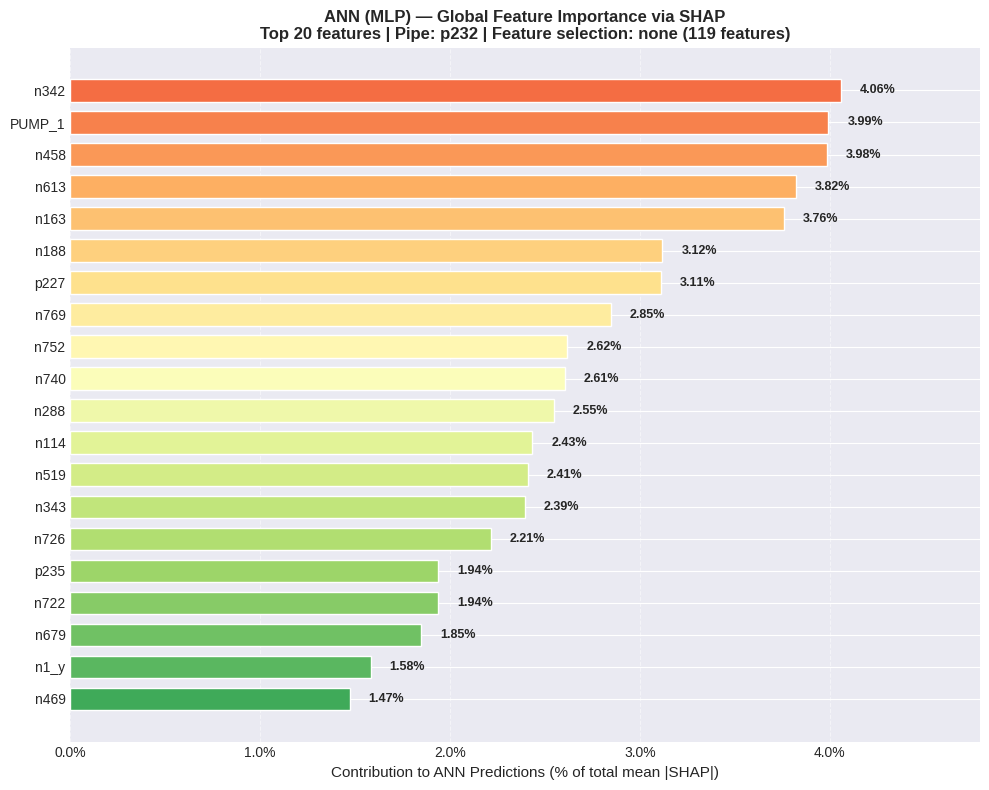

✓ Global importance bar chart saved


In [49]:
# ── 11.5  Global Feature Importance — Mean |SHAP| Bar Chart ──────────────────
# For each feature, compute mean(|SHAP value|) across all explained rows.
# This gives a single importance score per feature that can be converted to
# a percentage — directly answering "how much does pressure vs demand matter?"

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)  # shape: (n_features,)
total_shap    = mean_abs_shap.sum()
shap_pct      = 100 * mean_abs_shap / total_shap          # percentage contribution

# Build a ranked DataFrame
shap_df = pd.DataFrame({
    'Feature'         : feature_names,
    'Mean_Abs_SHAP'   : mean_abs_shap,
    'Contribution_Pct': shap_pct
}).sort_values('Contribution_Pct', ascending=False).reset_index(drop=True)

shap_df['Rank'] = shap_df.index + 1

print('\n══ Top Feature Contributions (ANN / MLP) ══')
print(f'{"Rank":<6} {"Feature":<30} {"Mean|SHAP|":>12} {"Contribution %":>15}')
print('─' * 65)
for _, row in shap_df.head(TOP_N_FEATURES).iterrows():
    bar = '█' * int(row['Contribution_Pct'] / 1)
    print(f'{int(row["Rank"]):<6} {row["Feature"]:<30} {row["Mean_Abs_SHAP"]:>12.5f} {row["Contribution_Pct"]:>14.2f}%  {bar}')

print('─' * 65)
print(f'{"TOP-" + str(TOP_N_FEATURES) + " total":<36} {"":>12} {shap_df.head(TOP_N_FEATURES)["Contribution_Pct"].sum():>14.2f}%')
print(f'{"All features total":<36} {"":>12} {"100.00":>14}%')

# Plot
top = shap_df.head(TOP_N_FEATURES).iloc[::-1]   # reverse for horizontal bar (best on top)

fig, ax = plt.subplots(figsize=(10, max(5, TOP_N_FEATURES * 0.4)))
colours = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top)))[::-1]
bars = ax.barh(top['Feature'], top['Contribution_Pct'], color=colours, edgecolor='white', height=0.7)

# Annotate bars with percentage labels
for bar, pct in zip(bars, top['Contribution_Pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}%', va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlabel('Contribution to ANN Predictions (% of total mean |SHAP|)', fontsize=11)
ax.set_title(
    f'ANN (MLP) — Global Feature Importance via SHAP\n'
    f'Top {TOP_N_FEATURES} features | Pipe: {TARGET_PIPE} | '
    f'Feature selection: {FEATURE_SELECTION} ({len(feature_names)} features)',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xlim(0, top['Contribution_Pct'].max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_ann_global_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Global importance bar chart saved')


In [50]:
"""
BattLeDIM Dataset Preview
Displays the first few rows of each dataset used in the XAI leak detection notebook.
Update DATA_PATH to point to your local BattLeDIM folder.
"""

from pathlib import Path
import pandas as pd

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_PATH = Path('/content/drive/MyDrive/BattLeDIM')   # ← update if needed
N_ROWS    = 5                                           # rows to preview per file

FILE_PATHS = {
    'demands'  : DATA_PATH / '2018_SCADA_Demands.csv',
    'flows'    : DATA_PATH / '2018_SCADA_Flows.csv',
    'levels'   : DATA_PATH / '2018_SCADA_Levels.csv',
    'pressures': DATA_PATH / '2018_SCADA_Pressures.csv',
    'leakages' : DATA_PATH / '2018_Leakages.csv',
}

# ── Loader (mirrors the notebook's clean_and_load) ────────────────────────────
def load_preview(file_path: Path, n: int = N_ROWS) -> pd.DataFrame:
    """Load the first `n` rows from a semicolon-delimited SCADA CSV."""
    df = pd.read_csv(file_path, delimiter=';', nrows=n)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    for col in df.columns:
        if col != 'Timestamp' and df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)
    return df

# ── Preview each file ─────────────────────────────────────────────────────────
for name, path in FILE_PATHS.items():
    print(f"\n{'═' * 70}")
    print(f"  Dataset : {name.upper()}  ({path.name})")
    print(f"{'═' * 70}")

    try:
        df = load_preview(path)
        print(f"  Shape preview  : {N_ROWS} rows × {df.shape[1]} columns")
        print(f"  Columns ({df.shape[1]}) : {list(df.columns[:8])}"
              + (" ..." if df.shape[1] > 8 else ""))
        print()
        # Transpose for wide datasets so it's readable in the console
        if df.shape[1] > 10:
            print(df.iloc[:, :6].to_string(index=False))   # show first 6 cols
            print(f"  [... {df.shape[1] - 6} more columns not shown]")
        else:
            print(df.to_string(index=False))
    except FileNotFoundError:
        print(f"  ⚠  File not found: {path}")
        print("     Update DATA_PATH at the top of this script.")

print(f"\n{'═' * 70}")
print("  Done — update N_ROWS to change how many rows are shown.")
print(f"{'═' * 70}\n")


══════════════════════════════════════════════════════════════════════
  Dataset : DEMANDS  (2018_SCADA_Demands.csv)
══════════════════════════════════════════════════════════════════════
  Shape preview  : 5 rows × 83 columns
  Columns (83) : ['Timestamp', 'n1', 'n2', 'n3', 'n4', 'n6', 'n7', 'n8'] ...

          Timestamp    n1     n2     n3     n4     n6
2018-01-01 00:00:00 40.83 112.23  96.71 131.29 166.18
2018-01-01 00:05:00 40.20 166.05 239.53 136.21 154.48
2018-01-01 00:10:00 38.06 121.91  69.12 131.00 160.10
2018-01-01 00:15:00 37.24  33.15 139.01 155.02 244.34
2018-01-01 00:20:00 45.38 122.55  72.13 148.66 257.18
  [... 77 more columns not shown]

══════════════════════════════════════════════════════════════════════
  Dataset : FLOWS  (2018_SCADA_Flows.csv)
══════════════════════════════════════════════════════════════════════
  Shape preview  : 5 rows × 4 columns
  Columns (4) : ['Timestamp', 'p227', 'p235', 'PUMP_1']

          Timestamp  p227  p235  PUMP_1
2018-01-01 00:00